In [131]:
!pip install --quiet networkx matplotlib numpy

import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
import random
import threading
import time
import networkx as nx
import tracemalloc


In [132]:
# ── CONFIGURATION CONSTANTS ──
COMM_SPEED   = 100.0            # ft/s for comms signal
COMM_JITTER  = (1.0, 3.0)       # random delay in seconds
HAZARD_PENALTY = 1.5            # multiplier for “caution” edges

G = nx.Graph()

floors = 6
x_rooms = 8
y_rooms = 8

# Updated spacings
room_spacing_x = 24
room_spacing_y = 26
floor_spacing_z = 15  # vertical spacing between floors

room_ids = {}

for z in range(floors):
    for y in range(y_rooms):
        for x in range(x_rooms):
            room_num = z * 100 + 101 + (y * x_rooms + x)
            node_id = str(room_num)

            G.add_node(node_id,
                       type="room",
                       x=x * room_spacing_x,
                       y=y * room_spacing_y,
                       z=z * floor_spacing_z,  # this is the vertical separation
                       structural_integrity=1.0,
                       urgency=0.0,
                       gas_leak=False,
                       occupants=0,
                       trust_level=1.0)

            room_ids[(x, y, z)] = node_id

# ── DESIGNATE GAS MAIN IN A ROOM ──
# (for this example, put it in Room 101 at (0,0,0))
gas_room = room_ids[(0, 1, 0)]
G.nodes[gas_room]['has_gas_main'] = True
print(f"🔍 Gas main located at room {gas_room}")


🔍 Gas main located at room 109


In [133]:
# Connect horizontal (E/W) rooms in each row
for z in range(floors):
    for y in range(y_rooms):
        for x in range(x_rooms - 1):
            n1 = room_ids[(x, y, z)]
            n2 = room_ids[(x + 1, y, z)]
            G.add_edge(n1, n2,
                       edge_type="hallway",
                       status="open",
                       distance=room_spacing_x,
                       trust_score=1.0,
                       structural_risk=0.0,
                       hazard_level='healthy')
            if random.random() < 0.15:
                G[n1][n2]['hazard_level'] = 'caution'


# Connect vertical (N/S) outer columns only: left column (x=0), right column (x=3)
outer_cols = [0, x_rooms - 1]

for z in range(floors):
    for x in outer_cols:
        for y in range(y_rooms - 1):
            n1 = room_ids[(x, y, z)]
            n2 = room_ids[(x, y + 1, z)]
            G.add_edge(n1, n2,
                       edge_type="hallway",
                       status="open",
                       distance=room_spacing_y,
                       trust_score=1.0,
                       structural_risk=0.0,
                       hazard_level='healthy')
            if random.random() < 0.15:
                G[n1][n2]['hazard_level'] = 'caution'



In [134]:
# ── MULTIPLE ELEVATORS AND STAIRS ──
# Place elevators and stairs in opposite corners, at least min_dist apart.

min_dist = max(x_rooms, y_rooms) // 2

# Corners to choose from
corners = [(0,0), (0,y_rooms-1), (x_rooms-1,0), (x_rooms-1,y_rooms-1)]

# Pick two corners for elevators that are far apart
elevator_stack = [corners[0], corners[3]]   # front‑left and back‑right

# Pick the other two corners for stairs
stair_stack    = [corners[1], corners[2]]   # back‑left and front‑right

# Now add elevator edges
for x, y in elevator_stack:
    for z in range(floors-1):
        n1 = room_ids[(x, y, z)]
        n2 = room_ids[(x, y, z+1)]
        G.add_edge(n1, n2,
                   edge_type="elevator",
                   status="open",
                   distance=floor_spacing_z,
                   trust_score=1.0,
                   structural_risk=0.0,
                   hazard_level='healthy')

# And stair edges
for x, y in stair_stack:
    for z in range(floors-1):
        n1 = room_ids[(x, y, z)]
        n2 = room_ids[(x, y, z+1)]
        G.add_edge(n1, n2,
                   edge_type="stair",
                   status="open",
                   distance=floor_spacing_z,
                   trust_score=1.0,
                   structural_risk=0.0,
                   hazard_level='healthy')


In [135]:
# Check if the graph is fully connected
if nx.is_connected(G):
    print("✅ The hospital graph is fully connected.")
else:
    print("❌ The graph is NOT connected. There may be isolated rooms or missing edges.")


✅ The hospital graph is fully connected.


In [136]:
room_types = ["ward", "ICU", "OR", "storage", "lobby"]
for node, data in G.nodes(data=True):
    if data.get("type") == "room":
        G.nodes[node].update({
            "room_type": random.choice(room_types),
            "structural_integrity": 1.0,
            "temperature": 22.0,
            "gas_leak": False,
            # assign urgency on a 1–10 scale:
            "urgency": random.randint(1, 10),
            "lighting": 1.0,
            # occupancy 0–3
            "occupants": random.randint(0, 3),   # ← **note the comma here**
        })


In [137]:
# ── MARK ROOMS WITH ALL-EDGE BLOCKAGES ──
blocked_rooms = {
    n
    for n,d in G.nodes(data=True)
    if d.get("type")=="room"
    and all(
        G[n][nbr]["hazard_level"] == "blocked"
        for nbr in G.neighbors(n)
    )
}
print(f"🚧 Blocked rooms (no open corridors): {sorted(blocked_rooms)}")

# ── EXPLORER THAT RETURNS THE FULL SEQUENCE ──
def explore_with_sequence(G, start):
    visited = {start}
    stack   = [start]
    sequence = []

    while stack:
        current = stack[-1]
        sequence.append(current)

        # 1) sniff current room
        if G.nodes[current].get('gas_leak', False):
            return sequence, stack

        # 2) sense hazards (for record only)
        for nbr in G.neighbors(current):
            _ = G[current][nbr].get('hazard_level', 'healthy')

        # 3) pick a random, unvisited, unblocked neighbor
        nbrs = [
            nbr for nbr in G.neighbors(current)
            if nbr not in visited
            and G[current][nbr].get('hazard_level','healthy')!='blocked'
            and nbr not in blocked_rooms
        ]

        random.shuffle(nbrs)

        if nbrs:
            nxt = nbrs[0]
            visited.add(nxt)
            stack.append(nxt)
        else:
            stack.pop()

    return sequence, None


🚧 Blocked rooms (no open corridors): []


In [138]:
# 🚪 Add Exit Node between Room 102 and 103 (on floor 0)
room_102 = room_ids[(1, 0, 0)]  # This gives you "102"
room_103 = room_ids[(2, 0, 0)]  # This gives you "103"

# Get positions of each room
x1, y1, z1 = G.nodes[room_102]["x"], G.nodes[room_102]["y"], G.nodes[room_102]["z"]
x2, y2, z2 = G.nodes[room_103]["x"], G.nodes[room_103]["y"], G.nodes[room_103]["z"]

# Midpoint position
exit_x = (x1 + x2) / 2
exit_y = (y1 + y2) / 2
exit_z = z1  # same floor

# Create EXIT node
exit_node_id = "EXIT"
G.add_node(exit_node_id,
           type="exit",
           x=exit_x,
           y=exit_y,
           z=exit_z)

# Connect to both rooms
G.add_edge(room_102, exit_node_id,
           edge_type="exit",
           status="open",
           distance=10,
           trust_score=1.0,
           structural_risk=0.0)

G.add_edge(room_103, exit_node_id,
           edge_type="exit",
           status="open",
           distance=10,
           trust_score=1.0,
           structural_risk=0.0)

print(f"✅ Exit node placed between {room_102} and {room_103}")

print("Is EXIT in G.nodes?", exit_node_id in G.nodes())

# 🚪 Add a second EXIT node on opposite side (e.g., between Room 104 and 105 on floor 0)
room_104 = room_ids[(0, 2, 0)]  # Pick another pair on opposite side
room_105 = room_ids[(3, 2, 0)]
exit2_x = (G.nodes[room_104]['x'] + G.nodes[room_105]['x']) / 2
exit2_y = (G.nodes[room_104]['y'] + G.nodes[room_105]['y']) / 2
exit2_z = G.nodes[room_104]['z']

exit_node_id2 = "EXIT2"
G.add_node(exit_node_id2,
           type="exit",
           x=exit2_x,
           y=exit2_y,
           z=exit2_z)

G.add_edge(room_104, exit_node_id2,
           edge_type="exit",
           status="open",
           distance=10,
           trust_score=1.0,
           structural_risk=0.0)
G.add_edge(room_105, exit_node_id2,
           edge_type="exit",
           status="open",
           distance=10,
           trust_score=1.0,
           structural_risk=0.0)

print(f"✅ Second exit node placed between {room_104} and {room_105}")



import random

# 2) Define sensors & precompute their exploration paths
sensor_starts = random.sample(
    [n for n,d in G.nodes(data=True) if d['type']=='room'],
    4
)

sensor_paths = []
for s in sensor_starts:
    seq, _ = explore_with_sequence(G, s)   # unpack the two‑tuple
    sensor_paths.append(seq)

print("🔧 Sensors at:", sensor_starts)
print("🔧 Precomputed", len(sensor_paths), "DFS sequences.")

# … right after you do the for‑loop that fills sensor_paths …

# strip out any non‑room nodes (e.g. EXIT)
sensor_paths = [
    [n for n in seq if G.nodes[n]['type']=='room']
    for seq in sensor_paths
]



✅ Exit node placed between 102 and 103
Is EXIT in G.nodes? True
✅ Second exit node placed between 117 and 120
🔧 Sensors at: ['107', '443', '105', '133']
🔧 Precomputed 4 DFS sequences.


In [139]:
# ── TWO EXIT NODES ON OPPOSITE SIDES OF FLOOR 0 ──

exits = []
# Exit A between rooms (1,0,0) & (2,0,0)  — west side
for coords in [((1,0,0),(2,0,0)), ((x_rooms-3, y_rooms-1, 0),(x_rooms-2, y_rooms-1, 0))]:
    (x1,y1,z1), (x2,y2,z2) = coords
    room_a = room_ids[(x1,y1,z1)]
    room_b = room_ids[(x2,y2,z2)]
    x_mid = (G.nodes[room_a]['x'] + G.nodes[room_b]['x'])/2
    y_mid = (G.nodes[room_a]['y'] + G.nodes[room_b]['y'])/2
    exit_id = f"EXIT_{x1}{y1}"
    G.add_node(exit_id,
               type="exit",
               x=x_mid, y=y_mid, z=z1)
    G.add_edge(room_a, exit_id,
               edge_type="exit",
               status="open",
               distance=10,
               trust_score=1.0,
               structural_risk=0.0)
    G.add_edge(room_b, exit_id,
               edge_type="exit",
               status="open",
               distance=10,
               trust_score=1.0,
               structural_risk=0.0)
    exits.append(exit_id)

print(f"✅ Exit nodes placed: {exits}")

# ── PICK A “DEFAULT” EXIT NODE FOR ROBOTS TO START FROM ──
# (you can change exits[0] → exits[1] if you prefer the other exit)
exit_node_id = exits[0]
print(f"🔑 Using exit_node_id = {exit_node_id} for all robot dispatch")


✅ Exit nodes placed: ['EXIT_10', 'EXIT_57']
🔑 Using exit_node_id = EXIT_10 for all robot dispatch


In [140]:

for (x, y, z), room_id in room_ids.items():
    if x == x_rooms - 1:  # east-most column
        G.nodes[room_id]["structural_integrity"] = round(random.uniform(0.1, 0.4), 2)
        #G.nodes[room_id]["gas_leak"] = random.random() < 0.5
        G.nodes[room_id]["lighting"] = round(random.uniform(0.0, 0.3), 2)
        G.nodes[room_id]["urgency"] = round(random.uniform(0.7, 1.0), 2)


In [141]:
# ── MAJOR AND MINOR STRUCTURAL DAMAGE FROM “EARTHQUAKE” ──
# We'll create a Gaussian-like spread of damage centered on the east wing.

import math

epicenter_x = x_rooms - 1
sigma       = 1.5   # controls spread: 1.5 floors over = pretty localized

for (x, y, z), room_id in room_ids.items():
    # compute horizontal distance from epicenter (in columns)
    dist = abs(x - epicenter_x)
    # damage probability falls off with a Gaussian
    p_damage = math.exp(-0.5 * (dist/sigma)**2)
    if random.random() < p_damage:
        # major damage
        G.nodes[room_id]['structural_integrity'] = round(random.uniform(0.1, 0.4), 2)
    else:
        # minor or no damage
        if random.random() < 0.2:
            G.nodes[room_id]['structural_integrity'] = round(random.uniform(0.4, 0.7), 2)

# Now propagate that into corridor (edge) blockages/hazards:
for u, v, attr in G.edges(data=True):
    # if either end is badly damaged, higher chance corridor is blocked
    si_u = G.nodes[u].get('structural_integrity', 1.0)
    si_v = G.nodes[v].get('structural_integrity', 1.0)
    p_block = max(0, (1 - si_u)) * max(0, (1 - si_v))
    if random.random() < p_block:
        attr['status'] = 'blocked'
        attr['hazard_level'] = 'blocked'
    elif random.random() < 0.1:
        attr['hazard_level'] = 'caution'


In [142]:
# ── ENSURE EVERY EDGE HAS hazard_level ──
for u, v, attr in G.edges(data=True):
    if attr.get('status') == 'blocked':
        G[u][v]['hazard_level'] = 'blocked'
    elif 'hazard_level' not in attr:
        G[u][v]['hazard_level'] = 'healthy'


In [143]:
def assign_minor_hazards(G, x_range=None, z_range=None):
    """
    Randomly add minor hazard attributes to rooms.
    - x_range: tuple of x positions to target (e.g. (2, 4)), or None for all
    - z_range: tuple of z (floor) values to target (e.g. (0, 2)), or None for all
    """
    hazard_types = ["glass_shards", "obstruction", "slippery", "ceiling_damage"]
    affected = 0

    for n, d in G.nodes(data=True):
        if d.get("type") != "room":
            continue

        x = int(d["x"] // room_spacing_x)
        z = d["z"]

        if x_range and not (x_range[0] <= x <= x_range[1]):
            continue
        if z_range and not (z_range[0] <= z <= z_range[1]):
            continue

        for hazard in hazard_types:
            d[hazard] = random.random() < 0.1

        if any(d.get(h) for h in hazard_types):
            affected += 1

    print(f"✔️ Minor hazards assigned to {affected} rooms.")




In [144]:
assign_minor_hazards(G)



✔️ Minor hazards assigned to 126 rooms.


In [145]:
# Check how many rooms actually got hazards (Debug)
hazard_types = ["glass_shards", "obstruction", "slippery", "ceiling_damage"]
hazard_count = 0

for n, d in G.nodes(data=True):
    if d.get("type") != "room":
        continue
    if any(d.get(h, False) for h in hazard_types):
        print(f"⚠️ Room {n} has hazards: {[h for h in hazard_types if d.get(h, False)]}")
        hazard_count += 1

if hazard_count == 0:
    print("❌ No hazards assigned. Something is wrong.")
else:
    print(f"✅ {hazard_count} rooms have at least one hazard.")


⚠️ Room 104 has hazards: ['obstruction', 'slippery']
⚠️ Room 105 has hazards: ['ceiling_damage']
⚠️ Room 109 has hazards: ['slippery']
⚠️ Room 111 has hazards: ['ceiling_damage']
⚠️ Room 113 has hazards: ['obstruction']
⚠️ Room 115 has hazards: ['glass_shards']
⚠️ Room 116 has hazards: ['obstruction', 'ceiling_damage']
⚠️ Room 127 has hazards: ['glass_shards']
⚠️ Room 129 has hazards: ['glass_shards', 'obstruction']
⚠️ Room 137 has hazards: ['glass_shards']
⚠️ Room 140 has hazards: ['ceiling_damage']
⚠️ Room 142 has hazards: ['obstruction']
⚠️ Room 143 has hazards: ['glass_shards']
⚠️ Room 145 has hazards: ['glass_shards']
⚠️ Room 146 has hazards: ['ceiling_damage']
⚠️ Room 147 has hazards: ['glass_shards', 'slippery']
⚠️ Room 150 has hazards: ['ceiling_damage']
⚠️ Room 153 has hazards: ['obstruction']
⚠️ Room 154 has hazards: ['slippery']
⚠️ Room 161 has hazards: ['glass_shards', 'slippery']
⚠️ Room 201 has hazards: ['ceiling_damage']
⚠️ Room 202 has hazards: ['glass_shards', 'obstruc

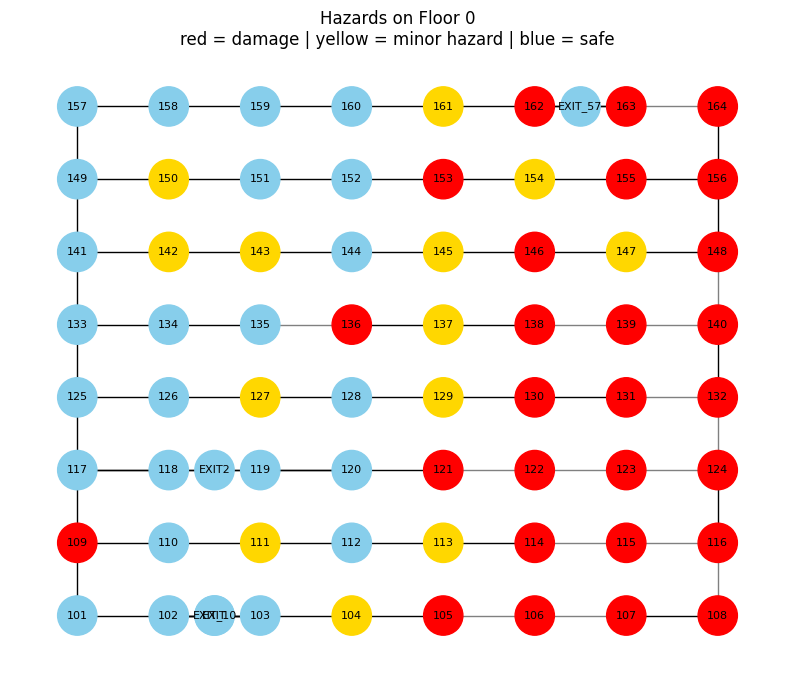

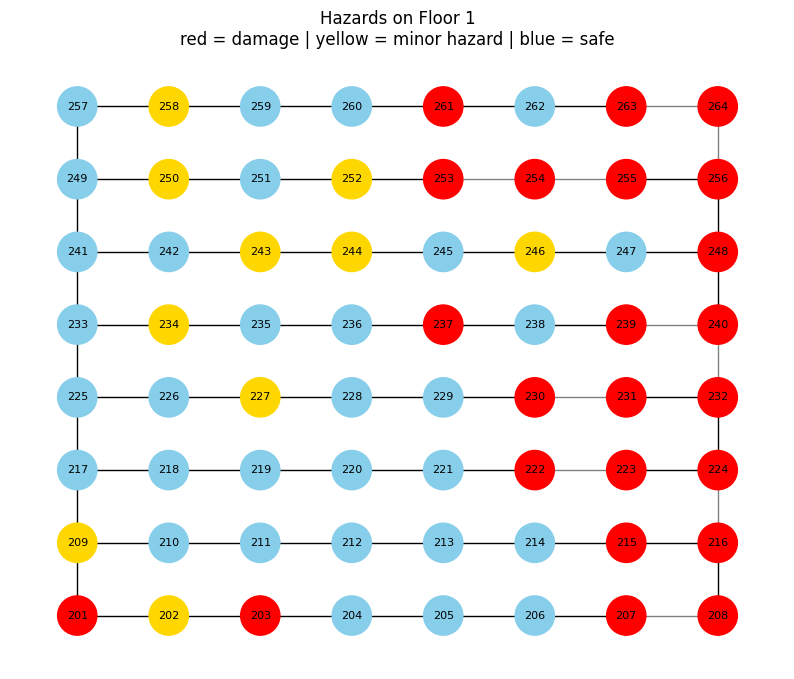

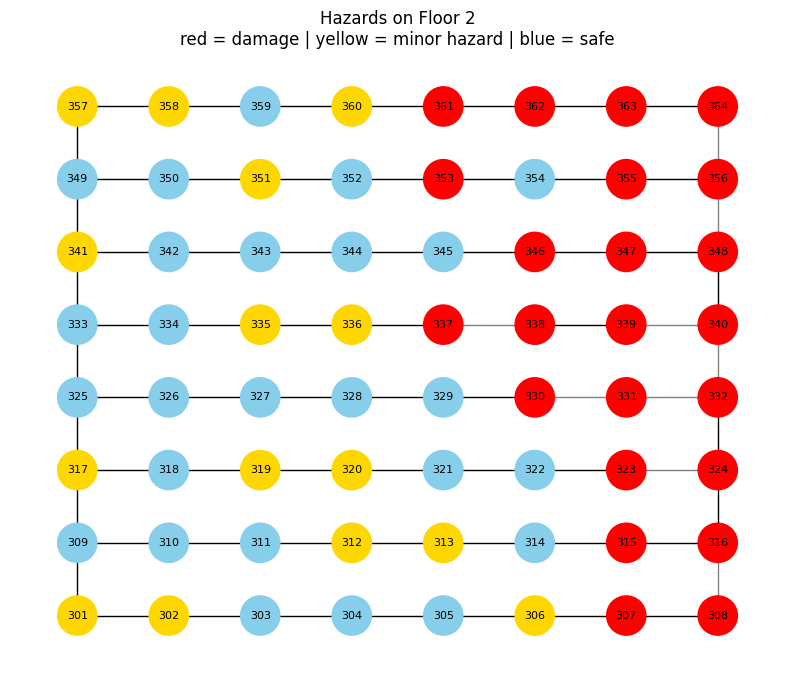

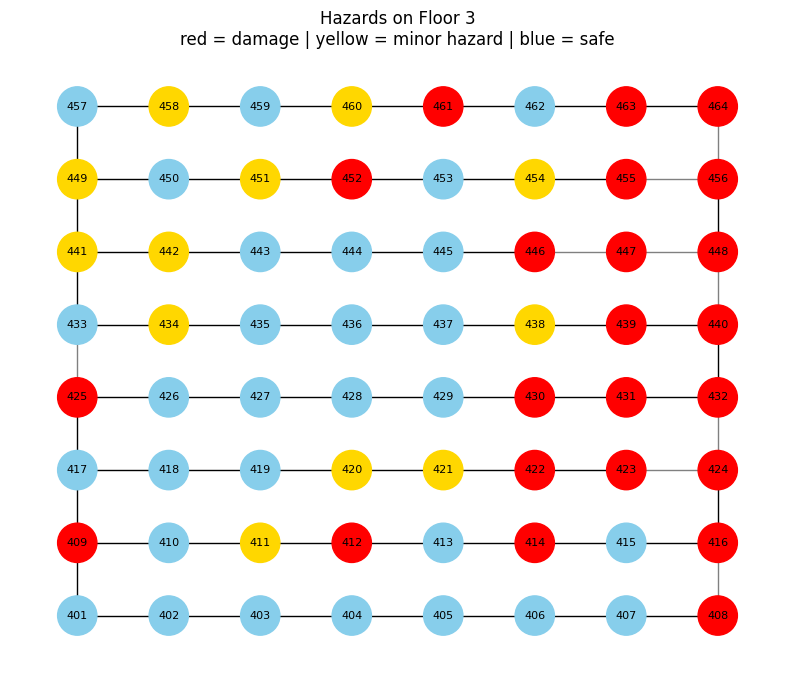

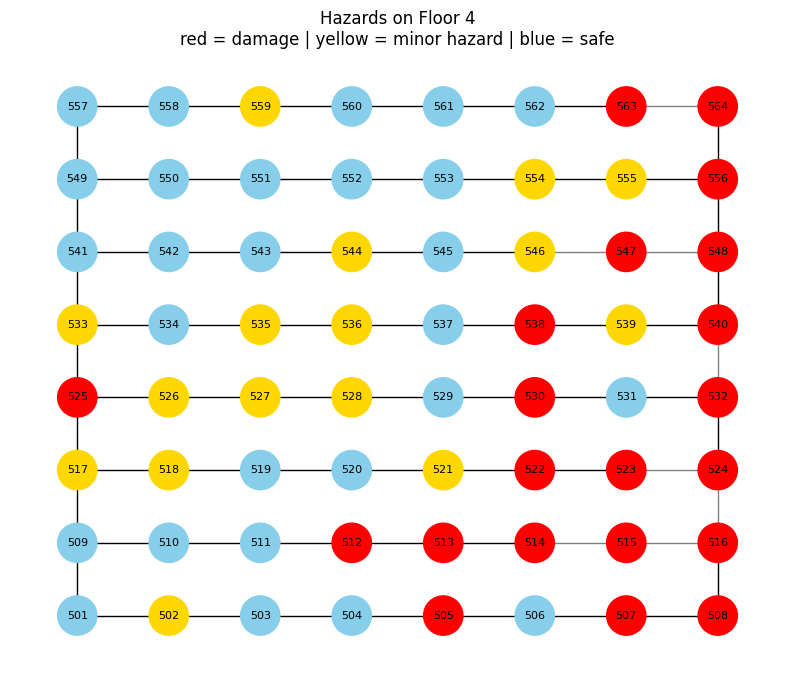

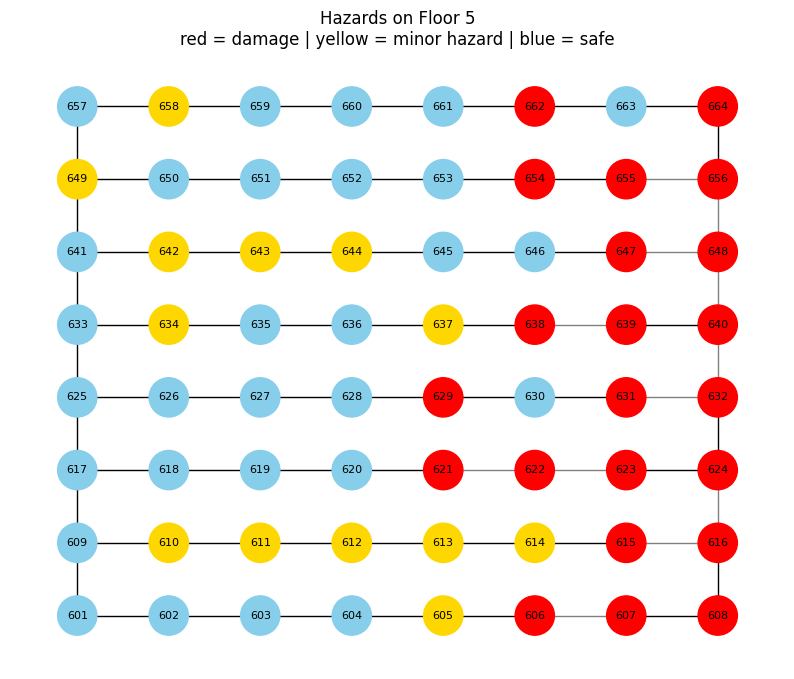

In [146]:
def visualize_hazards_on_floor(G, z_level):
    plt.figure(figsize=(10, 8))

    # Get nodes on this floor
    floor_nodes = [n for n, d in G.nodes(data=True) if d["z"] == z_level * floor_spacing_z]
    pos = {n: (G.nodes[n]['x'], G.nodes[n]['y']) for n in floor_nodes}

    # Determine node color
    node_colors = []
    for n in floor_nodes:
        d = G.nodes[n]
        integrity = d.get("structural_integrity", 1.0)
        has_minor_hazard = any([
            d.get("glass_shards", False),
            d.get("obstruction", False),
            d.get("slippery", False),
            d.get("ceiling_damage", False)
        ])

        if integrity < 0.5:
            node_colors.append("red")      # major structural damage
        elif has_minor_hazard:
            node_colors.append("gold")     # minor hazard only
        else:
            node_colors.append("skyblue")  # safe room



    # Draw nodes
    nx.draw_networkx_nodes(G, pos, nodelist=floor_nodes, node_color=node_colors, node_size=800)
    nx.draw_networkx_labels(G, pos, labels={n: n for n in floor_nodes}, font_size=8)

    # Draw edges
    floor_edges = [(u, v) for u, v in G.edges() if u in floor_nodes and v in floor_nodes]
    edge_colors = ["gray" if G[u][v].get("status") == "blocked" else "black" for u, v in floor_edges]
    nx.draw_networkx_edges(G, pos, edgelist=floor_edges, edge_color=edge_colors)

    plt.title(f"Hazards on Floor {z_level}\nred = damage | yellow = minor hazard | blue = safe")
    plt.axis("off")
    plt.show()

for z in range(floors):
    visualize_hazards_on_floor(G, z)


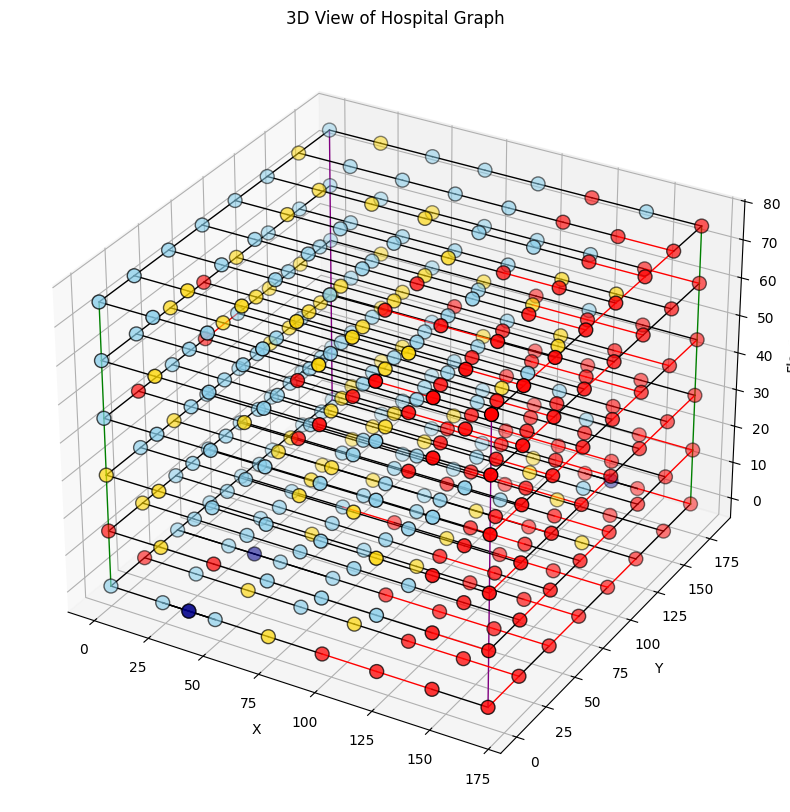

In [147]:
from mpl_toolkits.mplot3d import Axes3D

def visualize_hospital_3D(G):
    fig = plt.figure(figsize=(12, 10))
    ax = fig.add_subplot(111, projection='3d')

    # Position of each node
    node_pos = {}
    xs, ys, zs, colors = [], [], [], []

    for n, d in G.nodes(data=True):
        if d.get("type") not in ["room", "exit"]:
            continue
        x, y, z = d["x"], d["y"], d["z"]
        node_pos[n] = (x, y, z)
        xs.append(x)
        ys.append(y)
        zs.append(z)

        # Color nodes
        if d.get("type") == "exit":
            colors.append("darkblue")  # Exit node color
        else:
            integrity = d.get("structural_integrity", 1.0)
            has_minor_hazard = any([
                d.get("glass_shards", False),
                d.get("obstruction", False),
                d.get("slippery", False),
                d.get("ceiling_damage", False)
            ])

            if integrity < 0.5:
                colors.append("red")
            elif has_minor_hazard:
                colors.append("gold")
            else:
                colors.append("skyblue")

    # Draw nodes
    ax.scatter(xs, ys, zs, c=colors, s=100, edgecolors='k')

    # Draw edges
    for u, v, attr in G.edges(data=True):
        if u not in node_pos or v not in node_pos:
            continue
        x_vals = [node_pos[u][0], node_pos[v][0]]
        y_vals = [node_pos[u][1], node_pos[v][1]]
        z_vals = [node_pos[u][2], node_pos[v][2]]

        # Color edges based on priority
        if attr.get("edge_type") == "stair":
            color = "purple"
        elif attr.get("edge_type") == "elevator":
            color = "green"
        elif attr.get("hazard") == "debris":
            color = "yellow"
        elif attr.get("status") == "blocked":
            color = "red"
        else:
            color = "black"


        ax.plot(x_vals, y_vals, z_vals, color=color, linewidth=1)

    ax.set_xlabel("X")
    ax.set_ylabel("Y")
    ax.set_zlabel("Floor")
    ax.set_title("3D View of Hospital Graph")
    plt.show()

# Run it
visualize_hospital_3D(G)


In [148]:
# ── MARK ROOMS WITH ALL-EDGE BLOCKAGES ──
blocked_rooms = {
    n
    for n,d in G.nodes(data=True)
    if d.get("type")=="room"
    and all(
        G[n][nbr]["hazard_level"] == "blocked"
        for nbr in G.neighbors(n)
    )
}
print(f"🚧 Blocked rooms (no open corridors): {sorted(blocked_rooms)}")


🚧 Blocked rooms (no open corridors): ['106', '115', '122', '123', '139', '254', '331', '447', '515', '547', '622', '648']


In [149]:
# ── LOCAL KNOWLEDGE SHARING SETUP ──

import networkx as nx
import threading

# 1) Shared map: what rooms have been seen and where patients are
shared_map = {
    'discovered_nodes': set(),   # rooms we've “seen” so far
    'patients': {}               # mapping room_id → occupancy
}
map_lock = threading.Lock()

# 2) Local navigator: shortest path on the subgraph of discovered nodes
# ── LOCAL ROUTER WITH BLOCKED‐EDGE FILTERING ──




In [150]:
# ── SEED A GAS LEAK ──
# (Change the tuple if you want a different room)
leak_room = room_ids[(0, 0, 0)]
G.nodes[leak_room]['gas_leak'] = True
print(f"🔍 Gas leak seeded in room {leak_room}")


🔍 Gas leak seeded in room 101


In [152]:
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt


import time
import tracemalloc

def benchmark_algorithm(algorithm_fn, *args, **kwargs):
    """
    Run the given algorithm and measure runtime and peak memory.
    Returns: result, runtime (sec), peak_mem (MB)
    """
    tracemalloc.start()
    start_time = time.perf_counter()
    result = algorithm_fn(*args, **kwargs)
    end_time = time.perf_counter()
    current, peak = tracemalloc.get_traced_memory()
    tracemalloc.stop()
    runtime = end_time - start_time
    peak_mb = peak / 1e6
    return result, runtime, peak_mb


# --- Benchmark All-Pairs Dijkstra ---

room_nodes = [n for n, d in G.nodes(data=True) if d['type'] == 'room']

def all_pairs_dijkstra(G, nodes):
    # Returns shortest paths between all pairs of rooms
    return dict(nx.all_pairs_dijkstra_path_length(G, weight='distance'))

print("⏱️ Benchmarking all-pairs Dijkstra...")
dijkstra_result, dijkstra_time, dijkstra_mem = benchmark_algorithm(
    all_pairs_dijkstra, G, room_nodes
)
print(f"Dijkstra All-Pairs: {dijkstra_time:.2f} sec, Peak mem: {dijkstra_mem:.1f} MB")

def visualize_path_3D(G, path):
    """
    Draw the full hospital graph in light gray/blue,
    then overlay the agent's path in bold red.
    """
    # Build 3D positions for rooms and exit
    node_pos = {
        n: (d['x'], d['y'], d['z'])
        for n, d in G.nodes(data=True)
        if d.get("type") in ("room", "exit")
    }

    fig = plt.figure(figsize=(12, 10))
    ax = fig.add_subplot(111, projection='3d')

    # 1) Draw all edges in light gray
    for u, v in G.edges():
        if u in node_pos and v in node_pos:
            xs, ys, zs = zip(node_pos[u], node_pos[v])
            ax.plot(xs, ys, zs, color='lightgray', linewidth=1)

    # 2) Draw all nodes (rooms in skyblue, exit in darkblue)
    for n, (x, y, z) in node_pos.items():
        color = 'darkblue' if G.nodes[n]['type'] == 'exit' else 'skyblue'
        ax.scatter(x, y, z, c=color, s=50, edgecolors='k', alpha=0.6)

    # 3) Overlay the path edges in red
    for i in range(len(path) - 1):
        u, v = path[i], path[i + 1]
        if u in node_pos and v in node_pos:
            xs, ys, zs = zip(node_pos[u], node_pos[v])
            ax.plot(xs, ys, zs, color='red', linewidth=3)

    # 4) Highlight the path nodes in red
    for n in path:
        if n in node_pos:
            x, y, z = node_pos[n]
            ax.scatter(x, y, z, c='red', s=100, edgecolors='k')

    ax.set_xlabel("X")
    ax.set_ylabel("Y")
    ax.set_zlabel("Z (floor)")
    ax.set_title("3D Hospital Graph with Agent Path (red)")
    plt.show()


⏱️ Benchmarking all-pairs Dijkstra...
Dijkstra All-Pairs: 1.52 sec, Peak mem: 7.2 MB


In [154]:
import random

# ── EXPLORER THAT RETURNS THE FULL SEQUENCE ──
def explore_with_sequence(G, start):
    visited = {start}
    stack   = [start]
    sequence = []

    while stack:
        current = stack[-1]
        sequence.append(current)

        # 1) sniff current room
        if G.nodes[current].get('gas_leak', False):
            return sequence, stack

        # 2) sense hazards (for record only)
        for nbr in G.neighbors(current):
            _ = G[current][nbr].get('hazard_level', 'healthy')

        # 3) pick a random, unvisited, unblocked neighbor
        nbrs = [
            nbr for nbr in G.neighbors(current)
            if nbr not in visited
            and G[current][nbr].get('hazard_level','healthy')!='blocked'
            and nbr not in blocked_rooms            # <- skip fully blocked rooms
        ]

        random.shuffle(nbrs)

        if nbrs:
            nxt = nbrs[0]
            visited.add(nxt)
            stack.append(nxt)
        else:
            stack.pop()

    return sequence, None

# ── 3D VISUALIZER FOR THE EXPLORATION SEQUENCE ──
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt

def visualize_exploration_3D(G, sequence):
    node_pos = {
        n: (d['x'], d['y'], d['z'])
        for n, d in G.nodes(data=True)
        if d.get("type") in ("room","exit")
    }

    fig = plt.figure(figsize=(12,10))
    ax  = fig.add_subplot(111, projection='3d')

    # faint hospital graph
    for u, v in G.edges():
        if u in node_pos and v in node_pos:
            xs, ys, zs = zip(node_pos[u], node_pos[v])
            ax.plot(xs, ys, zs, color='lightgray', linewidth=1)

    # rooms & exit
    for n,(x,y,z) in node_pos.items():
        color = 'darkblue' if G.nodes[n]['type']=='exit' else 'skyblue'
        ax.scatter(x,y,z, c=color, s=50, edgecolors='k', alpha=0.6)

    # exploration in orange
    for i in range(len(sequence)-1):
        u, v = sequence[i], sequence[i+1]
        if u in node_pos and v in node_pos:
            xs, ys, zs = zip(node_pos[u], node_pos[v])
            ax.plot(xs, ys, zs, color='orange', linewidth=2)

    # step‐number labels
    for idx, n in enumerate(sequence):
        if n in node_pos:
            x,y,z = node_pos[n]
            ax.text(x, y, z, str(idx), color='red', fontsize=8, zorder=10)
            ax.scatter(x, y, z, c='red', s=80, edgecolors='k')

    ax.set_xlabel("X")
    ax.set_ylabel("Y")
    ax.set_zlabel("Z (floor)")
    ax.set_title("3D Exploration Sequence (orange) with Step Numbers")
    plt.show()


🔎 Full exploration sequence: 303 → 304 → 305 → 306 → 307 → 308 → 208 → 216 → 215 → 214 → 213 → 212 → 211 → 210 → 209 → 201 → 202 → 203 → 204 → 205 → 206 → 207 → 206 → 205 → 204 → 203 → 202 → 201 → 101
🛣️ Leak found! Final path: 303 → 304 → 305 → 306 → 307 → 308 → 208 → 216 → 215 → 214 → 213 → 212 → 211 → 210 → 209 → 201 → 101


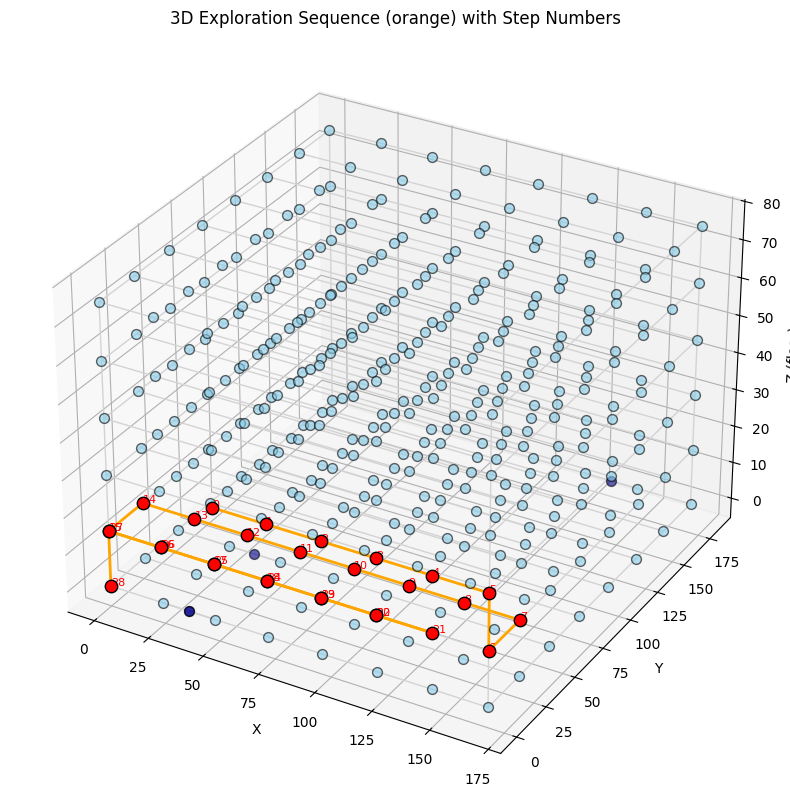

In [155]:
# ── RUN & VISUALIZE FULL EXPLORATION ──
start_room = room_ids[(2, 0, 2)]  # "303"
sequence, path = explore_with_sequence(G, start_room)

print("🔎 Full exploration sequence:", " → ".join(sequence))
if path:
    print("🛣️ Leak found! Final path:", " → ".join(path))
else:
    print("❌ Leak not found from", start_room)

visualize_exploration_3D(G, sequence)


In [156]:
#trying second interesting scenarion where we check for patients
def explore_for_patients(G, start):
    """
    DFS + backtracking sensor bot that records any room with occupants>0.
    Returns the exploration sequence and a dict mapping room_id→occupants.
    """
    visited = {start}
    stack   = [start]
    sequence = []
    found    = {}

    while stack:
        current = stack[-1]
        sequence.append(current)

        # record occupants if any
        occ = G.nodes[current].get('occupants', 0)
        if occ > 0:
            found[current] = occ

        # sense hazards (but don’t use for sensor)
        for nbr in G.neighbors(current):
            _ = G[current][nbr].get('hazard_level','healthy')

        # pick next unvisited, unblocked neighbor
        nbrs = [
            nbr for nbr in G.neighbors(current)
            if nbr not in visited
            and G[current][nbr].get('hazard_level','healthy')!='blocked'
            and nbr not in blocked_rooms            # <- skip fully blocked rooms
        ]

        nbrs.sort(key=lambda n: random.random())  # shuffle
        if nbrs:
            nxt = nbrs[0]
            visited.add(nxt)
            stack.append(nxt)
        else:
            stack.pop()

    return sequence, found


In [157]:
def navigate_and_return(G, start, target, speed=0.8):
    """
    Greedy, local‐knowledge evacuation bot:
      1) navigate from `start` to `target`,
      2) then back to `start`.
    Returns two lists: path_out, path_back.
    """
    def navigate(G, start, goal):
        visited = {start}
        path = [start]
        while path[-1] != goal:
            cur = path[-1]
            nbrs = []
            for nbr in G.neighbors(cur):
                lvl = G[cur][nbr].get('hazard_level','healthy')
                # skip blocked edges, visited rooms, or fully-blocked rooms
                if lvl=='blocked' or nbr in visited or nbr in blocked_rooms:
                    continue

                # heuristic = euclid to goal + travel penalty
                x1,y1 = G.nodes[nbr]['x'], G.nodes[nbr]['y']
                x2,y2 = G.nodes[goal]['x'],G.nodes[goal]['y']
                dist_est = ((x1-x2)**2 + (y1-y2)**2)**0.5
                score = dist_est + traversal_time(cur, nbr, speed)
                nbrs.append((score, nbr))

            if not nbrs:
                path.pop()
                if not path:
                    return None
                continue

            nxt = min(nbrs, key=lambda x: x[0])[1]
            visited.add(nxt)
            path.append(nxt)
        return path

    path_out  = navigate(G, start, target)
    path_back = navigate(G, target, start) if path_out else None
    return path_out, path_back


In [158]:
# ── SUM UP REAL TRAVERSAL TIMES AT 4 FT/S ──
def path_travel_time(G, path, speed=4.0):
    total = 0.0
    for u, v in zip(path, path[1:]):
        total += traversal_time(u, v, speed)
    return total

# ── LOCAL‐KNOWLEDGE SENSOR+ROBOT DRIVER ──

import threading

# ─── RESET shared_map BEFORE EACH EXPERIMENT ───
shared_map = {
    'discovered_nodes': set(),
    'patients': {}
}
map_lock   = threading.Lock()

rescue_log     = []
coverage_rooms = set()
lock           = threading.Lock()

sensor_starts = [
    room_ids[(0, 0, 0)],  # Room 101
    room_ids[(1, 1, 1)],  # Room 206
    room_ids[(2, 1, 2)]   # Room 307
]
print("🔧 Active sensors:", sensor_starts)

# ── LOCAL ROUTER WITH DEBUG ─




🔧 Active sensors: ['101', '210', '311']


In [159]:
# ── LOCAL VS GLOBAL COMPARISON SETUP ──
import threading, time, math

# snapshot initial patient counts
initial_room_occ = {
    n: d['occupants']
    for n, d in G.nodes(data=True)
    if d.get('type') == 'room' and d['occupants'] > 0
}

# ── SANITY CHECK: list patients per room & total ──
print("🔍 Sanity check: initial patient distribution")
total_patients = 0
for room, occ in sorted(initial_room_occ.items()):
    print(f"Room {room}: {occ} patient{'s' if occ>1 else ''}")
    total_patients += occ
print(f"🏥 Total patients across all rooms: {total_patients}")
print("────────────────────────────────────────────")


# shared state for local threaded dispatch
map_lock            = threading.Lock()
cleared_rooms       = set()
rooms_with_patients = set(initial_room_occ)
local_rescue_log    = []
coverage_rooms      = set()

# ── HELPERS ──
def traversal_time(u, v, speed=4.0):
    e = G[u][v]
    if e['hazard_level']=='blocked':
        return float('inf')
    penalty = HAZARD_PENALTY if e['hazard_level']=='caution' else 1.0
    return (e['distance']/speed) * penalty


def navigate_local(start, goal, speed=4.0):
    """
    Greedy local navigator: falls back to a true shortest-path
    on the subgraph without blocked edges.
    """
    # Build a subgraph excluding blocked corridors
    H = G.copy()
    for u, v, attr in list(H.edges(data=True)):
        if attr.get('hazard_level') == 'blocked':
            H.remove_edge(u, v)

    try:
        # weight is pure distance / speed
        return nx.shortest_path(
            H, start, goal,
            weight=lambda u, v, d: d['distance'] / speed
        )
    except nx.NetworkXNoPath:
        return None


def choose_best_target(current_pos, speed=4.0):
    best, best_cost = None, float('inf')
    for r in rooms_with_patients - cleared_rooms:
        p = navigate_local(current_pos, r, speed)
        if not p:
            continue
        c = sum(traversal_time(u,v,speed) for u,v in zip(p,p[1:]))
        if c < best_cost:
            best_cost, best = c, r
    return best

# ── SUM UP REAL TRAVERSAL TIMES AT 4 FT/S ──
def path_travel_time(G, path, speed=4.0):
    total = 0.0
    for u, v in zip(path, path[1:]):
        total += traversal_time(u, v, speed)
    return total

# ── LOCAL‐KNOWLEDGE SENSOR+ROBOT DRIVER (deduped) ──
import threading

rescue_log     = []
coverage_rooms = set()
lock           = threading.Lock()

sensor_starts = [
    room_ids[(0, 0, 0)],  # Room 101
    room_ids[(1, 1, 1)],  # Room 206
    room_ids[(2, 1, 2)]   # Room 307
]
print("🔧 Active sensors:", sensor_starts)

def sensor_worker(start):
    # 1) Explore & collect local findings
    seq, found = explore_for_patients(G, start)

    # 2) Publish those findings to shared_map
    with map_lock:
        shared_map['discovered_nodes'].update(seq)
        for room_id, occ in found.items():
            if room_id not in shared_map['patients']:
                shared_map['patients'][room_id] = occ

    # 3) Log header & coverage
    log = [
        f"🔎 Sensor @ {start} explored: {' → '.join(seq)}",
        f"👥 Shared patient map now: {shared_map['patients']}"
    ]
    with lock:
        coverage_rooms.update(n for n in seq if G.nodes[n]['type']=='room')

    # 4) Dispatch robots—but only for rooms still in shared_map
    for room_id in list(found):
        with map_lock:
            occ = shared_map['patients'].pop(room_id, 0)
        if occ == 0:
            log.append(f"⚠️ Skipping {room_id}, already cleared")
            continue

        path = navigate_local(exit_node_id, room_id, speed=4.0)
        if path:
            t_out   = path_travel_time(G, path,  speed=4.0)
            t_back  = path_travel_time(G, list(reversed(path)), speed=4.0)
            t_total = t_out + t_back

            # zero out the room so no other sensor thinks there are still patients
            G.nodes[room_id]['occupants'] = 0

            rescue_log.append({
                'sensor': start, 'room': room_id,
                'patients': occ, 'time': t_total
            })
            log.append(
                f"🚑 Rescued {occ} from {room_id} "
                f"(out {t_out:.2f}s + back {t_back:.2f}s = {t_total:.2f}s)"
            )
        else:
            rescue_log.append({
                'sensor': start, 'room': room_id,
                'patients': occ, 'time': float('inf')
            })
            log.append(f"❌ Rescue failed for {room_id}")

    # 5) Flush this sensor’s log
    with lock:
        print("\n".join(log), "\n")

# Launch sensors in parallel
threads = []
for s in sensor_starts:
    t = threading.Thread(target=sensor_worker, args=(s,))
    threads.append(t)
    t.start()
for t in threads:
    t.join()

# Summarize deduped metrics
times   = [e['time'] for e in rescue_log if e['time']<float('inf')]
rescued = sum(e['patients'] for e in rescue_log if e['time']<float('inf'))

first_t = min(times) if times else float('nan')
max_t   = max(times) if times else float('nan')
total   = sum(1 for n,d in G.nodes(data=True) if d.get('type')=='room')
covered = len(coverage_rooms)
pct     = covered/total*100

print("📊 DEDUPED LOCAL Metrics:")
print(f"- Patients rescued      : {rescued}")
print(f"- Time to first rescue  : {first_t:.2f}s")
print(f"- Slowest single rescue : {max_t:.2f}s")
print(f"- Area coverage         : {covered}/{total} rooms ({pct:.1f}%)")


# ── GLOBAL‐OPTIMAL BASELINE PLANNER (excluding blocked rooms) ──

# ── RESTORE occupants for the global run ──
for node_id, occ in initial_room_occ.items():
    G.nodes[node_id]['occupants'] = occ

# 1) Collect all reachable rooms with patients, skipping blocked_rooms
room_occ = {
    n: occ
    for n, occ in initial_room_occ.items()
    if n not in blocked_rooms
}

print(f"🚩 Rooms with patients (global, excl. blocked): {len(room_occ)}")

# 2) Compute optimal path/time for each patient room
global_log = []
times      = []
rescued    = 0

for room_id, occ in room_occ.items():
    # find a path on the subgraph without blocked edges
    path = navigate_local(exit_node_id, room_id, speed=4.0)
    if path is None:
        global_log.append(f"⚠️ No open path to {room_id}, skipping")
        continue

    # compute travel time
    t = path_travel_time(G, path, speed=4.0)
    times.append(t)
    rescued += occ

    global_log.append(
        f"🚑 [GLOBAL] {occ} patient(s) from {room_id}: "
        f"len={len(path)-1}, time={t:.2f}s"
    )

# 3) Print per‐room global dispatch info
print("\n".join(global_log), "\n")

# 4) Compute & print global metrics
first_time   = min(times) if times else float('nan')
max_time     = max(times) if times else float('nan')
total_rooms  = sum(1 for n,d in G.nodes(data=True) if d.get('type')=='room')
reachable    = len(room_occ)
coverage_pct = len(times) / reachable * 100 if reachable else 0.0

print("📊 GLOBAL Metrics:")
print(f"- Patients rescued      : {rescued}")
print(f"- Time to first rescue  : {first_time:.2f}s")
print(f"- Slowest single rescue : {max_time:.2f}s")
print(f"- Area coverage         : {len(times)}/{reachable} rooms ({coverage_pct:.1f}%)")




🔍 Sanity check: initial patient distribution
Room 102: 2 patients
Room 103: 1 patient
Room 104: 1 patient
Room 107: 1 patient
Room 108: 1 patient
Room 109: 3 patients
Room 110: 2 patients
Room 111: 1 patient
Room 112: 3 patients
Room 113: 2 patients
Room 114: 2 patients
Room 115: 3 patients
Room 116: 3 patients
Room 117: 2 patients
Room 118: 2 patients
Room 120: 3 patients
Room 121: 2 patients
Room 122: 2 patients
Room 123: 2 patients
Room 125: 2 patients
Room 126: 2 patients
Room 127: 1 patient
Room 129: 3 patients
Room 131: 3 patients
Room 132: 1 patient
Room 134: 3 patients
Room 135: 2 patients
Room 137: 1 patient
Room 140: 3 patients
Room 141: 3 patients
Room 142: 3 patients
Room 143: 2 patients
Room 144: 2 patients
Room 145: 1 patient
Room 146: 2 patients
Room 148: 3 patients
Room 149: 3 patients
Room 150: 2 patients
Room 151: 2 patients
Room 152: 3 patients
Room 153: 3 patients
Room 156: 1 patient
Room 157: 2 patients
Room 159: 2 patients
Room 160: 2 patients
Room 161: 2 patients

In [160]:
import heapq
import random

class RobotAgent:
    def __init__(self, id, start_node):
        self.id = id
        self.current_node = start_node
        self.state = 'idle'  # 'idle', 'to_patient', 'rescuing', 'to_exit'
        self.path = []
        self.progress = 0.0
        self.target_patient_room = None
        self.rescue_time_left = 0
        self.total_distance = 0
        self.rescue_log = []
        self.failed_targets = set()

    def assign_rescue(self, path, patient_room, rescue_time):
        self.state = 'to_patient'
        self.path = path
        self.target_patient_room = patient_room
        self.progress = 0.0
        self.rescue_time_left = rescue_time

    def move_along_path(self, G, speed):
        # Move towards next node in the path, updating position/progress.
        if not self.path or self.current_node == self.path[-1]:
            return
        u = self.current_node
        v = self.path[1]  # Next node on path
        edge = G[u][v]
        distance = edge['distance']
        travel = min(speed, distance - self.progress)
        self.progress += travel
        self.total_distance += travel
        if abs(self.progress - distance) < 1e-6:
            self.current_node = v
            self.path = self.path[1:]
            self.progress = 0.0

    def at_target(self):
        return self.state == 'to_patient' and self.current_node == self.target_patient_room

    def at_exit(self, exit_node):
        return self.current_node == exit_node and self.state == 'to_exit'

def benchmark_algorithm(algorithm_fn, *args, **kwargs):
    """
    Run the given algorithm and measure runtime and peak memory.
    Returns: result, runtime (sec), peak_mem (MB)
    """
    tracemalloc.start()
    start_time = time.perf_counter()
    result = algorithm_fn(*args, **kwargs)
    end_time = time.perf_counter()
    current, peak = tracemalloc.get_traced_memory()
    tracemalloc.stop()
    runtime = end_time - start_time
    peak_mb = peak / 1e6
    return result, runtime, peak_mb



def simulate_rescue(
    G,
    robot_start_nodes,
    patient_rooms,
    exit_node,
    assign_next_target_func,
    robot_speed=4.0,
    rescue_time_range=(10,20),
    knowledge_update_events=None,
    time_step=1.0,
    max_steps=10000,
    sensor_starts=None,
    sensor_paths=None
):
    import heapq
    import random

    COMM_SPEED = 30.0  # ft/sec, or whatever you want for communication delay
    COMM_JITTER = (0.5, 3.0)  # min/max random extra delay in seconds

    # Initialize robots
    robots = [RobotAgent(i, robot_start_nodes[i]) for i in range(len(robot_start_nodes))]
    time = 0.0
    rescued_patients = 0
    failed_patients = set()
    active_patients = set(patient_rooms)
    patient_status = {room: 'pending' for room in patient_rooms}
    logs = []
    knowledge_queue = []
    local_knowledge = set(robot_start_nodes)  # rooms robots start at

    if knowledge_update_events:
        for (t_event, room, occ) in knowledge_update_events:
            heapq.heappush(knowledge_queue, (t_event, room, occ))

    # --- MAIN SIMULATION LOOP ---
    while (active_patients or any(r.state != 'idle' for r in robots)) and time < max_steps:

        # ── SENSOR EXPLORATION STEP (push events into knowledge_queue) ──
        if sensor_starts and sensor_paths:
            for idx, sensor in enumerate(sensor_starts):
                if sensor_paths[idx]:
                    next_room = sensor_paths[idx].pop(0)
                    # compute 3D distance to EXIT for latency
                    sx, sy, sz = (G.nodes[next_room][k] for k in ('x','y','z'))
                    ex, ey, ez = (G.nodes[exit_node][k] for k in ('x','y','z'))
                    dist = ((sx-ex)**2 + (sy-ey)**2 + (sz-ez)**2)**0.5
                    delay = dist/COMM_SPEED + random.uniform(*COMM_JITTER)
                    heapq.heappush(knowledge_queue, (time + delay, next_room, G.nodes[next_room]['occupants']))

        # ── PROCESS SENSOR UPDATES ──
        while knowledge_queue and knowledge_queue[0][0] <= time:
            _, room, occ = heapq.heappop(knowledge_queue)
            local_knowledge.add(room)
            if room in active_patients and patient_status[room] == 'pending':
                patient_status[room] = 'discovered'

        # Check for patient expirations at each step
        expired_patients = set()
        for room in active_patients:
            expiration_time = G.nodes[room].get('patient_expiration', float('inf'))
            if time >= expiration_time:
                expired_patients.add(room)
                patient_status[room] = 'failed'
        active_patients -= expired_patients
        failed_patients |= expired_patients

        # For each idle robot: assign new target using the planning function
        for i, robot in enumerate(robots):
            if robot.state == 'idle':
                available_targets = [r for r in active_patients if r in local_knowledge]
                if available_targets:
                    path, target, rescue_time = assign_next_target_func(
                        robot, available_targets, G, exit_node, time, local_knowledge, rescue_time_range
                    )
                    if path:
                        robot.assign_rescue(path, target, rescue_time)
                        patient_status[target] = 'assigned'

        # Simulate robot movements
        for robot in robots:
            if robot.state == 'to_patient':
                robot.move_along_path(G, robot_speed * time_step)
                if robot.at_target():
                    robot.state = 'rescuing'
            elif robot.state == 'rescuing':
                robot.rescue_time_left -= time_step
                if robot.rescue_time_left <= 0:
                    # Finished rescue, plan path to exit
                    try:
                        path = nx.shortest_path(G, robot.current_node, exit_node, weight='distance')
                    except Exception:
                        path = [robot.current_node, exit_node]
                    robot.state = 'to_exit'
                    robot.path = path
                    robot.progress = 0.0
            elif robot.state == 'to_exit':
                robot.move_along_path(G, robot_speed * time_step)
                if robot.at_exit(exit_node):
                    # Rescue complete
                    robot.state = 'idle'
                    rescued_patients += 1
                    patient_status[robot.target_patient_room] = 'rescued'
                    logs.append({
                        'robot': robot.id,
                        'patient_room': robot.target_patient_room,
                        'total_distance': robot.total_distance,
                        'rescue_time': time,
                        'completed_at': time
                    })
                    robot.total_distance = 0  # reset for next rescue
                    active_patients.discard(robot.target_patient_room)
                    robot.target_patient_room = None

        time += time_step

    # Record failed rescues
    for r in active_patients:
        failed_patients.add(r)
        patient_status[r] = 'failed'

    return {
        'total_time': time,
        'rescued_patients': rescued_patients,
        'failed_patients': len(failed_patients),
        'logs': logs,
        'patient_status': patient_status
    }



# --- Helper: Assign path to exit (for robot after rescue)
def assign_path_func(robot, targets, G, exit_node, time, local_knowledge, rescue_time_range):
    # Placeholder: returns direct shortest path to exit
    target = targets[0]
    try:
        path = nx.shortest_path(G, robot.current_node, target, weight='distance')
        rescue_time = random.uniform(*rescue_time_range)
        return path, target, rescue_time
    except nx.NetworkXNoPath:
        return None, target, 0


In [161]:
def assign_next_target_Astar(robot, available_targets, G, exit_node, time, local_knowledge, rescue_time_range):
    # Plan to the *nearest* target patient (by A*; all info known)
    best_path = None
    best_target = None
    best_cost = float('inf')
    for target in available_targets:
        try:
            path = nx.astar_path(G, robot.current_node, target, weight='distance')
            cost = sum(G[u][v]['distance'] for u, v in zip(path, path[1:]))
            if cost < best_cost:
                best_cost = cost
                best_target = target
                best_path = path
        except nx.NetworkXNoPath:
            continue
    if best_path:
        rescue_time = random.uniform(*rescue_time_range)
        return best_path, best_target, rescue_time
    else:
        return None, None, 0


In [162]:
# For A*, robots know all patient rooms from the start—so every event is at time 0
patient_rooms = [n for n, d in G.nodes(data=True) if d.get('type') == 'room' and d['occupants'] > 0]
robot_start_nodes = [exit_node_id] * 6  # 6 robots at EXIT

# Knowledge events: all patient rooms are revealed instantly
knowledge_events_Astar = []
for room in patient_rooms:
    occ = G.nodes[room]['occupants']
    if occ > 0:
        knowledge_events_Astar.append((0, room, occ))


In [ ]:
def run_astar_global():
    return simulate_rescue(
        G,
        robot_start_nodes=robot_start_nodes,
        patient_rooms=patient_rooms,
        exit_node=exit_node_id,
        assign_next_target_func=assign_next_target_Astar,
        robot_speed=4.0,
        rescue_time_range=(10, 20),
        knowledge_update_events=knowledge_events_Astar,
        time_step=1.0
    )

print("⏱️ Benchmarking global A* planner...")
astar_result, astar_time, astar_mem = benchmark_algorithm(run_astar_global)
print(f"A* Global: {astar_time:.2f} sec, Peak mem: {astar_mem:.1f} MB")


results_Astar = simulate_rescue(
    G,
    robot_start_nodes=robot_start_nodes,
    patient_rooms=patient_rooms,
    exit_node=exit_node_id,
    assign_next_target_func=assign_next_target_Astar,
    robot_speed=4.0,
    rescue_time_range=(10, 20),
    knowledge_update_events=knowledge_events_Astar,
    time_step=1.0,
    sensor_starts=sensor_starts,     # <-- your list of 4 sensor node IDs
    sensor_paths=sensor_paths        # <-- your list of 4 DFS sequences
)

print("RESULTS_ASTAR:", results_Astar)
print(" available keys:", list(results_Astar.keys()))



⏱️ Benchmarking global A* planner...


In [ ]:
import pandas as pd

Astar_logs = results_Astar['logs']
df_astar = pd.DataFrame(Astar_logs)
if not df_astar.empty:
    print("\n===== A* Global Knowledge Rescue Log =====")
    print(df_astar)
    print("\n===== A* Global Summary =====")
    print(f"Total simulation time: {results_Astar['total_time']:.1f} sec")
    print(f"Patients rescued:     {results_Astar['rescued_patients']}")
    print(f"Patients failed:      {results_Astar['failed_patients']}")
    print(f"Avg. path distance:   {df_astar['total_distance'].mean():.1f} ft")
    print(f"Avg. rescue duration: {df_astar['rescue_time'].mean():.1f} sec")
else:
    print("No patients rescued in A* run.")


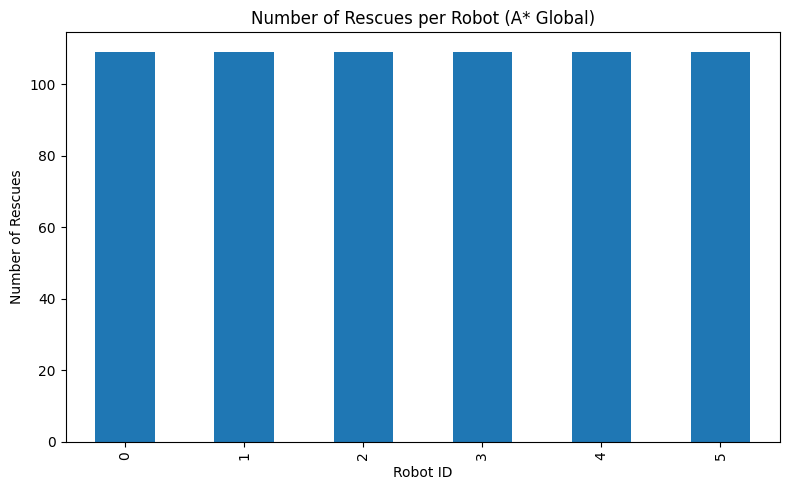

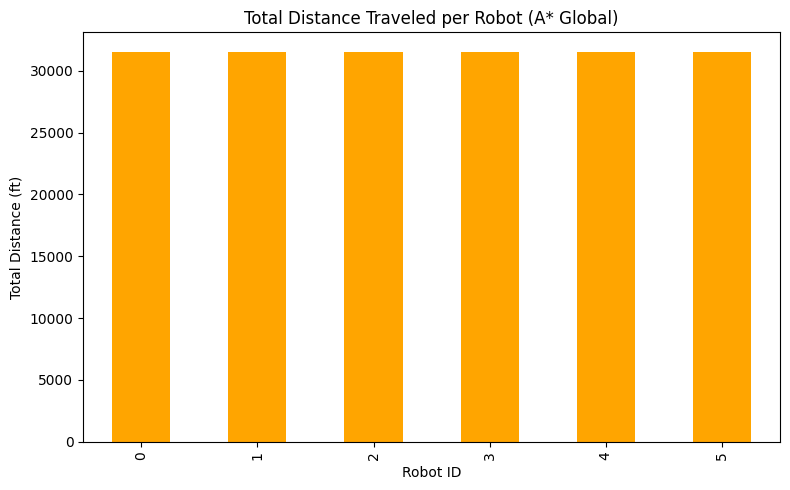

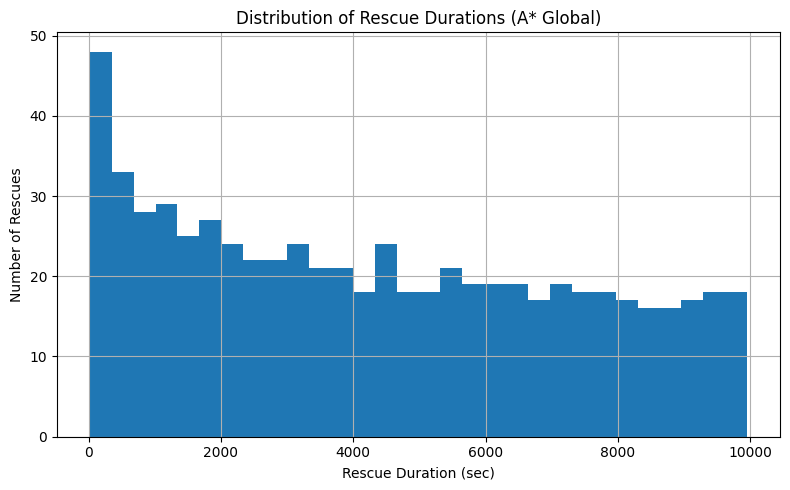

In [ ]:
import matplotlib.pyplot as plt

# 1. Number of rescues per robot
plt.figure(figsize=(8,5))
rescues_per_robot = df_astar.groupby('robot').size()
rescues_per_robot.plot(kind='bar')
plt.title('Number of Rescues per Robot (A* Global)')
plt.xlabel('Robot ID')
plt.ylabel('Number of Rescues')
plt.tight_layout()
plt.show()

# 2. Total distance traveled by each robot
plt.figure(figsize=(8,5))
df_astar.groupby('robot')['total_distance'].sum().plot(kind='bar', color='orange')
plt.title('Total Distance Traveled per Robot (A* Global)')
plt.xlabel('Robot ID')
plt.ylabel('Total Distance (ft)')
plt.tight_layout()
plt.show()

# 3. Distribution of rescue durations
plt.figure(figsize=(8,5))
df_astar['rescue_time'].hist(bins=30)
plt.title('Distribution of Rescue Durations (A* Global)')
plt.xlabel('Rescue Duration (sec)')
plt.ylabel('Number of Rescues')
plt.tight_layout()
plt.show()


In [ ]:
summary_table = df_astar.groupby('robot').agg(
    num_rescues=('rescue_time', 'count'),
    total_distance=('total_distance', 'sum'),
    avg_distance=('total_distance', 'mean'),
    avg_rescue_time=('rescue_time', 'mean')
)
print(summary_table)


       num_rescues  total_distance  avg_distance  avg_rescue_time
robot                                                            
0              109         31520.0    289.174312      4325.458716
1              109         31520.0    289.174312      4354.678899
2              109         31520.0    289.174312      4358.642202
3              109         31520.0    289.174312      4337.834862
4              109         31520.0    289.174312      4327.311927
5              109         31520.0    289.174312      4340.321101


In [122]:
def assign_next_target_Dstar(robot, available_targets, G, exit_node, time, local_knowledge, rescue_time_range):
    # Pick nearest patient (by current local knowledge)
    best_path = None
    best_target = None
    best_cost = float('inf')
    for target in available_targets:
        # Build subgraph of currently known nodes/edges (excluding blocked)
        H = G.subgraph(local_knowledge).copy()
        for u, v, data in list(H.edges(data=True)):
            if data.get('hazard_level', 'healthy') == 'blocked':
                H.remove_edge(u, v)
        try:
            path = nx.shortest_path(H, robot.current_node, target, weight='distance')
            cost = sum(H[u][v]['distance'] for u, v in zip(path, path[1:]))
            if cost < best_cost:
                best_cost = cost
                best_target = target
                best_path = path
        except nx.NetworkXNoPath:
            continue
    if best_path:
        rescue_time = random.uniform(*rescue_time_range)
        return best_path, best_target, rescue_time
    else:
        return None, None, 0


In [ ]:
# Sensors: 4 sensors at same locations as before (or randomly sample as desired)
sensor_starts = random.sample([n for n in G.nodes if G.nodes[n].get('type') == 'room'], 4)
robot_start_nodes = [exit_node_id] * 6

# ── BUILD knowledge_events_Dstar WITH SENSOR MOVEMENT & DELAY ──
knowledge_events_Dstar = []
# assume sensor_starts list already defined with 4 start nodes
sensor_positions = {s: G.nodes[s] for s in sensor_starts}
for sensor in sensor_starts:
    seq, found = explore_for_patients(G, sensor)
    current_time = 0.0
    for room, occ in found.items():
        # estimate comm delay to each robot start
        robot_pos = np.array([G.nodes[robot_start_nodes[0]]['x'],
                              G.nodes[robot_start_nodes[0]]['y'],
                              G.nodes[robot_start_nodes[0]]['z']])
        sensor_pos = np.array([G.nodes[room]['x'],
                               G.nodes[room]['y'],
                               G.nodes[room]['z']])
        delay = np.linalg.norm(sensor_pos - robot_pos)/COMM_SPEED \
                + random.uniform(*COMM_JITTER)
        knowledge_events_Dstar.append((current_time + delay, room, occ))



In [ ]:
results_Dstar = simulate_rescue(
    G,
    robot_start_nodes=[exit_node_id] * 6,
    patient_rooms=[n for n,d in G.nodes(data=True) if d['type']=='room' and d['occupants']>0],
    exit_node=exit_node_id,
    assign_next_target_func=assign_next_target_Dstar,
    robot_speed=4.0,
    rescue_time_range=(10, 20),
    knowledge_update_events=knowledge_events_Dstar,
    time_step=1.0,
    sensor_starts=sensor_starts,
    sensor_paths=[list(p) for p in sensor_paths]
)


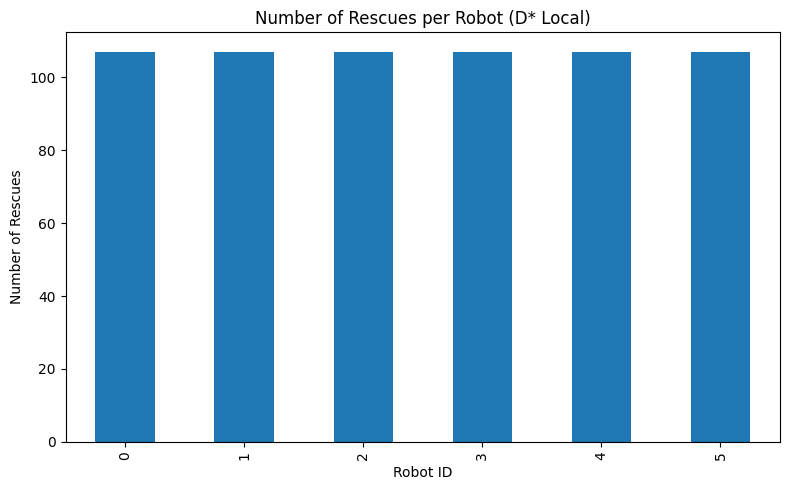

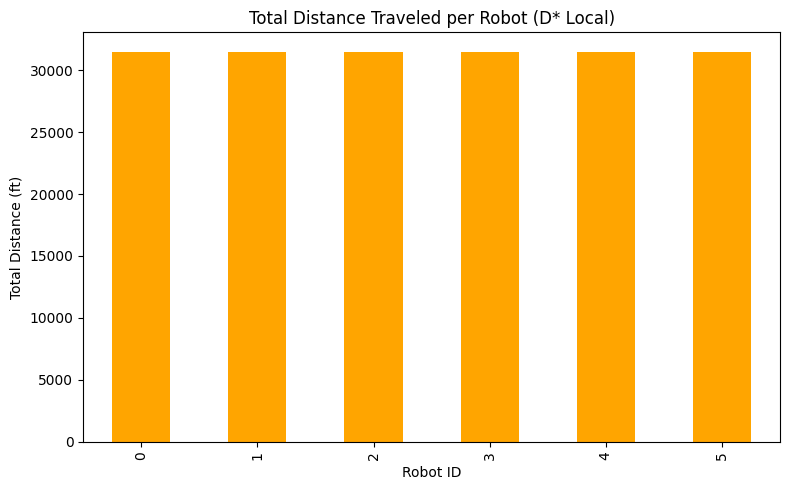

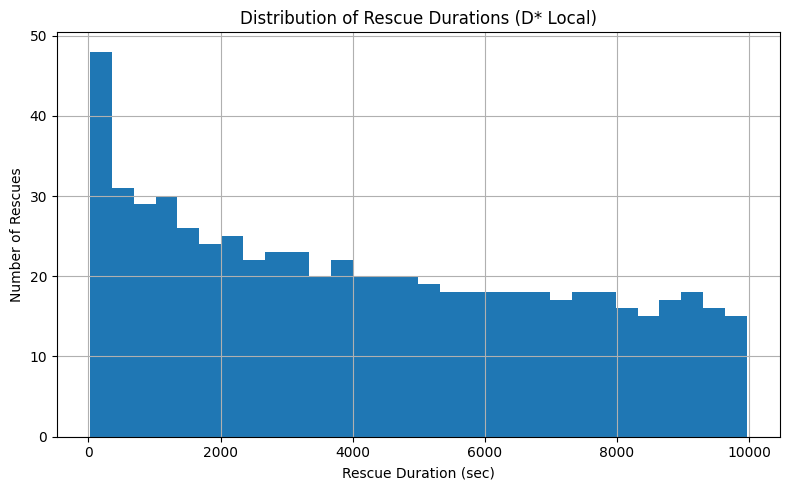


===== D* Local Knowledge Rescue Log =====
 robot patient_room  rescue_time  total_distance  completed_at
     0          102        20.00           20.00         20.00
     2          102        20.00           20.00         20.00
     4          102        20.00           20.00         20.00
     5          102        23.00           20.00         23.00
     3          102        24.00           20.00         24.00
     1          102        27.00           20.00         27.00
     0          101        49.00           68.00         49.00
     2          101        51.00           68.00         51.00
     4          101        53.00           68.00         53.00
     1          101        57.00           68.00         57.00
     5          101        58.00           68.00         58.00
     3          101        62.00           68.00         62.00
     4          201        91.00           98.00         91.00
     2          201        93.00           98.00         93.00
     0      

In [123]:
df_dstar = pd.DataFrame(results_Dstar['logs'])

if not df_dstar.empty:
    # Number of rescues per robot
    plt.figure(figsize=(8,5))
    df_dstar.groupby('robot').size().plot(kind='bar')
    plt.title('Number of Rescues per Robot (D* Local)')
    plt.xlabel('Robot ID')
    plt.ylabel('Number of Rescues')
    plt.tight_layout()
    plt.show()

    # Total distance per robot
    plt.figure(figsize=(8,5))
    df_dstar.groupby('robot')['total_distance'].sum().plot(kind='bar', color='orange')
    plt.title('Total Distance Traveled per Robot (D* Local)')
    plt.xlabel('Robot ID')
    plt.ylabel('Total Distance (ft)')
    plt.tight_layout()
    plt.show()

    # Distribution of rescue durations
    plt.figure(figsize=(8,5))
    df_dstar['rescue_time'].hist(bins=30)
    plt.title('Distribution of Rescue Durations (D* Local)')
    plt.xlabel('Rescue Duration (sec)')
    plt.ylabel('Number of Rescues')
    plt.tight_layout()
    plt.show()

    # Table of results
    print("\n===== D* Local Knowledge Rescue Log =====")
    display_cols = ['robot', 'patient_room', 'rescue_time', 'total_distance', 'completed_at']
    print(df_dstar[display_cols].to_string(index=False, float_format="%.2f"))

    print("\n===== D* Local Summary =====")
    print(f"Total simulation time: {results_Dstar['total_time']:.1f} sec")
    print(f"Patients rescued:     {results_Dstar['rescued_patients']}")
    print(f"Patients failed:      {results_Dstar['failed_patients']}")
    print(f"Avg. path distance:   {df_dstar['total_distance'].mean():.1f} ft")
    print(f"Avg. rescue duration: {df_dstar['rescue_time'].mean():.1f} sec")
else:
    print("No patients rescued in D* run.")


In [ ]:
# Gather per-run summary metrics
def planner_summary(df, total_time, rescued, failed):
    return {
        'num_rescues': rescued,
        'patients_failed': failed,
        'total_sim_time (s)': total_time,
        'avg_rescue_time (s)': df['rescue_time'].mean() if not df.empty else float('nan'),
        'avg_path_distance (ft)': df['total_distance'].mean() if not df.empty else float('nan'),
        'total_distance (ft)': df['total_distance'].sum() if not df.empty else float('nan'),
        'rescues_per_robot': df.groupby('robot').size().mean() if not df.empty else float('nan')
    }

summary_astar = planner_summary(df_astar, results_Astar['total_time'],
                                results_Astar['rescued_patients'], results_Astar['failed_patients'])
summary_dstar = planner_summary(df_dstar, results_Dstar['total_time'],
                                results_Dstar['rescued_patients'], results_Dstar['failed_patients'])


In [124]:
import pandas as pd

# Create summary comparison DataFrame
summary_df = pd.DataFrame([summary_astar, summary_dstar], index=['A* (Global)', 'D* (Local)'])
print("\n===== Planner Comparison Table =====")
print(summary_df.round(2))



===== Planner Comparison Table =====
             num_rescues  patients_failed  total_sim_time (s)  \
A* (Global)          654              194             10000.0   
D* (Local)           642              196             10000.0   

             avg_rescue_time (s)  avg_path_distance (ft)  total_distance (ft)  \
A* (Global)              4340.71                  289.17             189120.0   
D* (Local)               4295.14                  294.15             188844.0   

             rescues_per_robot  
A* (Global)              109.0  
D* (Local)               107.0  


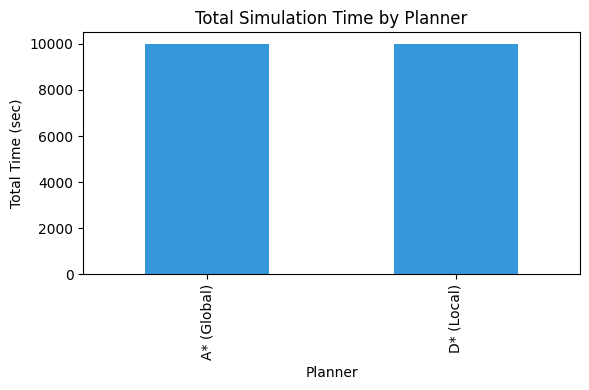

In [126]:
import matplotlib.pyplot as plt

# Example: Suppose these variables already exist:
# results_Astar['total_time'], results_Dstar['total_time']

sim_times = {
    "A* (Global)": results_Astar['total_time'],
    "D* (Local)": results_Dstar['total_time']
}

import pandas as pd

sim_time_df = pd.DataFrame.from_dict(sim_times, orient='index', columns=['Total Time (sec)'])

# Bar graph: total simulation time
sim_time_df.plot.bar(
    figsize=(6,4),
    legend=False,
    color=['#3498db', '#e67e22']
)
plt.title('Total Simulation Time by Planner')
plt.ylabel('Total Time (sec)')
plt.xlabel('Planner')
plt.tight_layout()
plt.show()


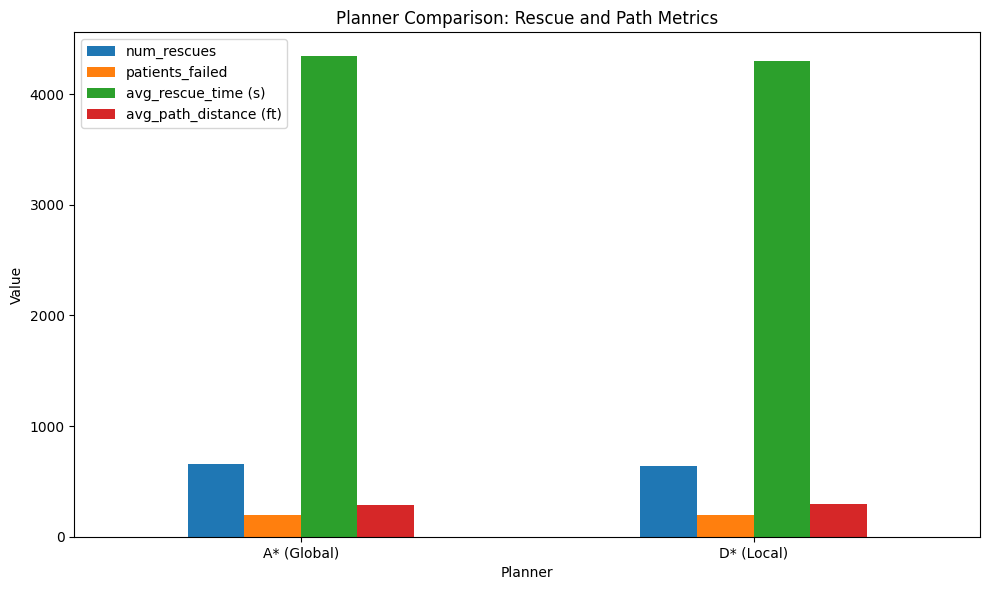

In [130]:
summary_astar = planner_summary(df_astar, results_Astar['total_time'],
                                results_Astar['rescued_patients'], results_Astar['failed_patients'])
summary_dstar = planner_summary(df_dstar, results_Dstar['total_time'],
                                results_Dstar['rescued_patients'], results_Dstar['failed_patients'])

import pandas as pd

metrics_df = pd.DataFrame([summary_astar, summary_dstar], index=['A* (Global)', 'D* (Local)'])


metrics_plot_cols = ['num_rescues', 'patients_failed', 'avg_rescue_time (s)', 'avg_path_distance (ft)']

metrics_df[metrics_plot_cols].plot.bar(
    figsize=(10,6)
)
plt.title('Planner Comparison: Rescue and Path Metrics')
plt.ylabel('Value')
plt.xlabel('Planner')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()
